# Configurations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import sklearn.decomposition
from sklearn.preprocessing import OneHotEncoder 
from sklearn.compose import ColumnTransformer
import seaborn as sns; sns.set()
import math
from typing import List
from types import SimpleNamespace

# Temporary
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import copy
import os
os.chdir("..")

# Data Preprocessing

In [2]:
# The column names in the NSL KDD dataset
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label",               # <-- attack label
    "difficulty"           # <-- the missing column!
]

train = pd.read_csv("data/KDDTrain+.txt", names=col_names)
test  = pd.read_csv("data/KDDTest+.txt",  names=col_names)

# Selected features
features = [
    # categorical
    "protocol_type", "service", "flag",

    # numeric
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "dst_host_srv_count", "dst_host_serror_rate",
    "logged_in", "root_shell", "su_attempted"
]

categorical = ["protocol_type", "service", "flag"]

numeric = [
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "dst_host_srv_count", "dst_host_serror_rate",
    "logged_in", "root_shell", "su_attempted"
]

preprocess = ColumnTransformer([ ("cat", OneHotEncoder(handle_unknown="ignore"), categorical), ("num", "passthrough", numeric) ])

# Training and testing set
X_train = train[features]
X_test  = test[features]

# Ensure string values are numerical
X_train = preprocess.fit_transform(X_train).toarray()
X_test  = preprocess.transform(X_test).toarray()

# Label normal traffic as 0 and attack traffic 1
# y_train = (train["label"] != "normal").astype(int).values
# y_test  = (test["label"] != "normal").astype(int).values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Fit on ALL labels so no unseen labels appear later
all_labels = pd.concat([train["label"], test["label"]], axis=0)
le.fit(all_labels)

# Now safely transform
y_train_full = le.transform(train["label"])
y_test       = le.transform(test["label"])

num_classes = len(le.classes_)
print("Number of classes:", num_classes)


# Shape of data
num_features = X_train.shape[1] # 94 features

# X_train is already preprocessed earlier
N = len(X_train)
val_size = int(0.2 * N)

# Apply the same split to encoded labels
y_val   = y_train_full[:val_size]
y_train = y_train_full[val_size:]

X_val   = X_train[:val_size]
X_train = X_train[val_size:]

Number of classes: 40


# Descriptive Statistics

In [3]:
# Build DataFrames
df_train = pd.DataFrame(X_train, columns=[f"f{i}" for i in range(X_train.shape[1])])
df_train["label"] = y_train

df_val = pd.DataFrame(X_val, columns=[f"f{i}" for i in range(X_val.shape[1])])
df_val["label"] = y_val

df_test = pd.DataFrame(X_test, columns=[f"f{i}" for i in range(X_test.shape[1])])
df_test["label"] = y_test

In [4]:
print("=== Train Descriptive Statistics ===")
display(df_train.describe())

print("=== Validation Descriptive Statistics ===")
display(df_val.describe())

print("=== Test Descriptive Statistics ===")
display(df_test.describe())

=== Train Descriptive Statistics ===


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f85,f86,f87,f88,f89,f90,f91,f92,f93,label
count,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,...,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000,100779.000000
mean,0.065847,0.815269,0.118884,0.001459,0.000506,0.006847,0.000020,0.007601,0.005596,0.005656,...,0.282172,0.120293,0.121416,0.661018,115.800226,0.284121,0.395975,0.001290,0.001042,15.784618
std,0.248016,0.388081,0.323653,0.038164,0.022490,0.082461,0.004455,0.086851,0.074600,0.074993,...,0.446883,0.320860,0.323978,0.439624,110.716415,0.444655,0.489062,0.035893,0.044201,3.852931
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.090000,10.000000,0.000000,0.000000,0.000000,0.000000,14.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,63.000000,0.000000,0.000000,0.000000,0.000000,16.000000
75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,255.000000,1.000000,1.000000,0.000000,0.000000,16.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,255.000000,1.000000,1.000000,1.000000,2.000000,35.000000


=== Validation Descriptive Statistics ===


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f85,f86,f87,f88,f89,f90,f91,f92,f93,label
count,25194.000000,25194.000000,25194.000000,25194.000000,25194.000000,25194.000000,25194.0,25194.000000,25194.000000,25194.000000,...,25194.000000,25194.000000,25194.000000,25194.000000,25194.000000,25194.000000,25194.000000,25194.000000,25194.000000,25194.000000
mean,0.065690,0.814757,0.119552,0.001588,0.000873,0.006827,0.0,0.007502,0.005795,0.006509,...,0.283740,0.118621,0.120251,0.660566,115.064103,0.285778,0.394777,0.001548,0.001350,15.780106
std,0.247745,0.388502,0.324444,0.039815,0.029538,0.082345,0.0,0.086289,0.075906,0.080420,...,0.447588,0.318735,0.322324,0.439626,110.648264,0.445306,0.488812,0.039315,0.048783,3.866669
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.090000,10.000000,0.000000,0.000000,0.000000,0.000000,14.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,61.000000,0.000000,0.000000,0.000000,0.000000,16.000000
75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,255.000000,1.000000,1.000000,0.000000,0.000000,16.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,255.000000,1.000000,1.000000,1.000000,2.000000,35.000000


=== Test Descriptive Statistics ===


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f85,f86,f87,f88,f89,f90,f91,f92,f93,label
count,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.0,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,0.046265,0.837473,0.116262,0.000577,0.000665,0.001996,0.0,0.002972,0.002040,0.001774,...,0.103635,0.238463,0.235179,0.740345,140.750532,0.097814,0.442202,0.002440,0.000266,15.773953
std,0.210063,0.368941,0.320545,0.024007,0.025787,0.044634,0.0,0.054436,0.045126,0.042086,...,0.298332,0.416118,0.416215,0.412496,111.783972,0.273139,0.496659,0.049334,0.021060,7.160315
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.250000,15.000000,0.000000,0.000000,0.000000,0.000000,14.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,168.000000,0.000000,0.000000,0.000000,0.000000,16.000000
75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.250000,0.072500,1.000000,255.000000,0.000000,1.000000,0.000000,0.000000,16.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,255.000000,1.000000,1.000000,1.000000,2.000000,39.000000


# Distribution Plots for Features

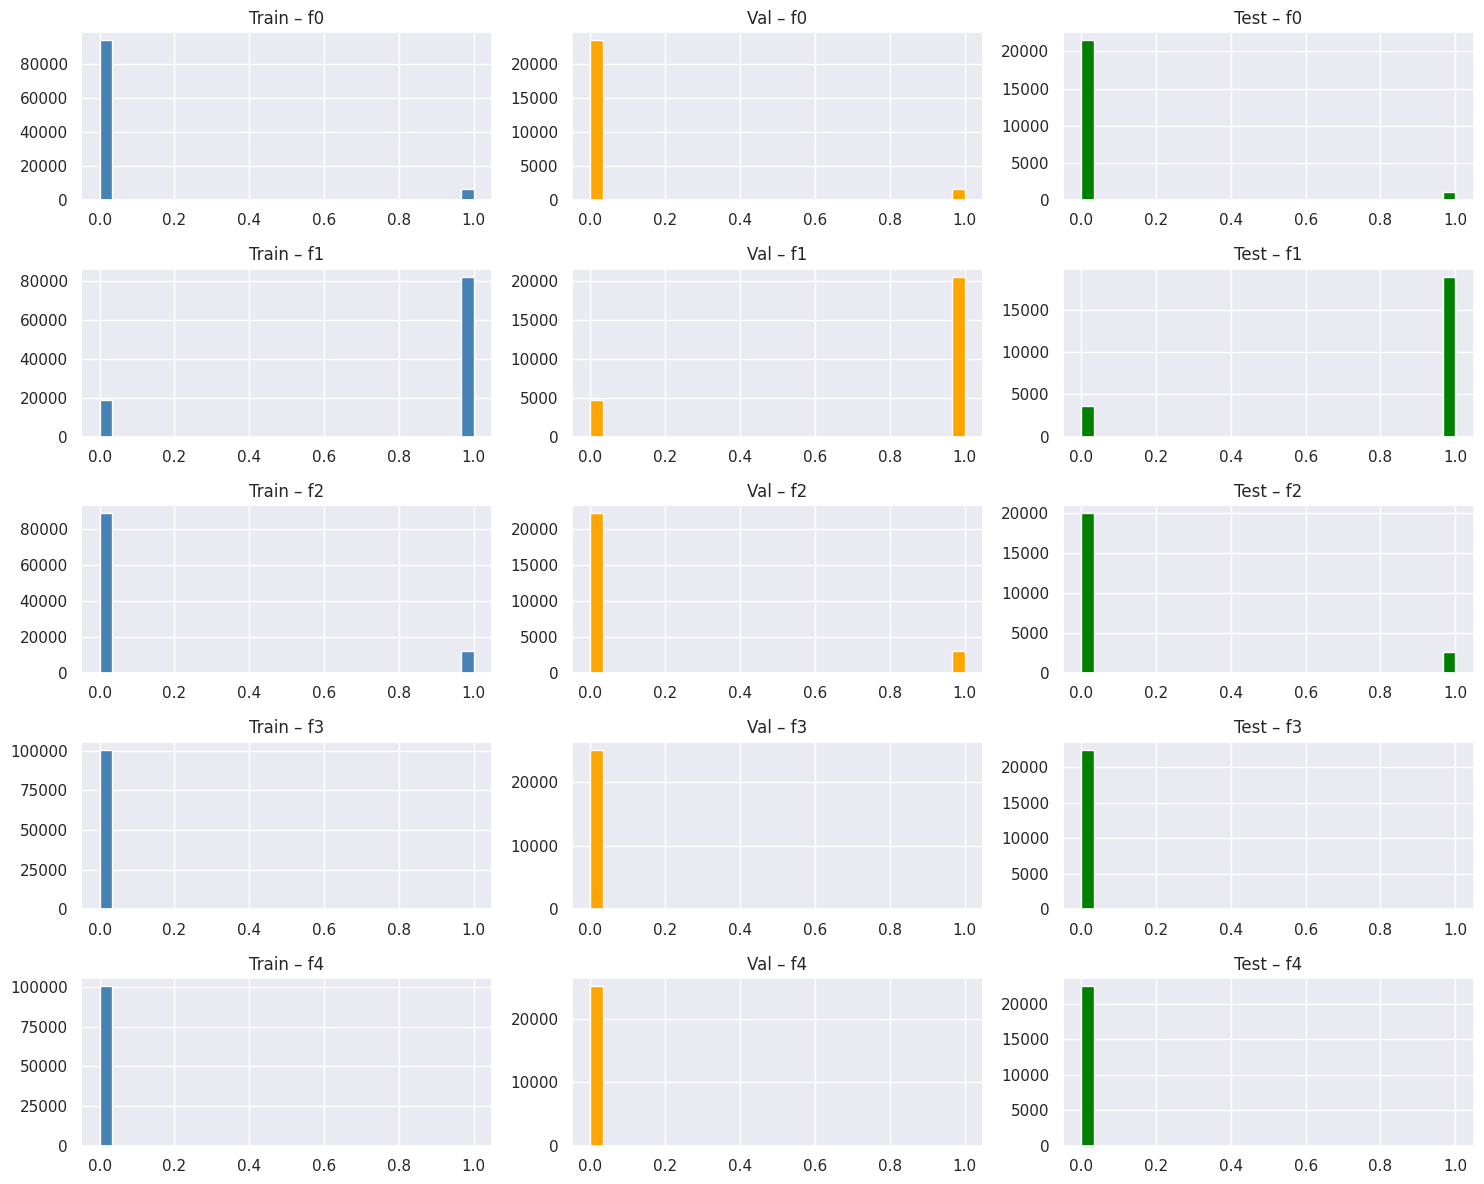

In [5]:
features_to_plot = [f"f{i}" for i in range(5)]

fig, axes = plt.subplots(len(features_to_plot), 3, figsize=(15, 12))

for row, feat in enumerate(features_to_plot):
    # Train
    axes[row, 0].hist(df_train[feat], bins=30, color="steelblue")
    axes[row, 0].set_title(f"Train – {feat}")

    # Validation
    axes[row, 1].hist(df_val[feat], bins=30, color="orange")
    axes[row, 1].set_title(f"Val – {feat}")

    # Test
    axes[row, 2].hist(df_test[feat], bins=30, color="green")
    axes[row, 2].set_title(f"Test – {feat}")

plt.tight_layout()
plt.show()

# Class Distributions

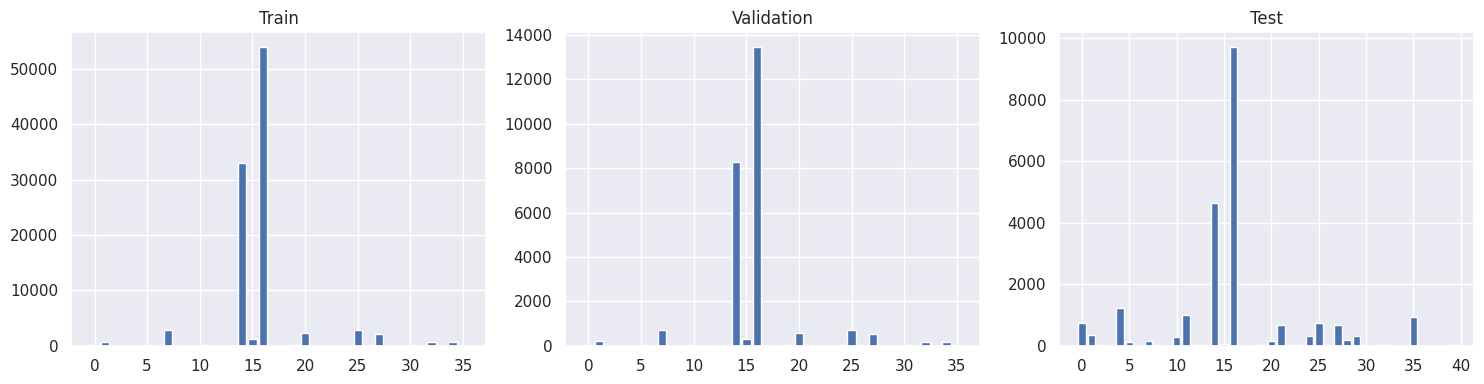

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Train
counts_train = np.bincount(y_train)
ax1.bar(np.arange(len(counts_train)), counts_train)
ax1.set_title("Train")

# Val
counts_val = np.bincount(y_val)
ax2.bar(np.arange(len(counts_val)), counts_val)
ax2.set_title("Validation")

# Test
counts_test = np.bincount(y_test)
ax3.bar(np.arange(len(counts_test)), counts_test)
ax3.set_title("Test")

plt.tight_layout()
plt.show()

Note: Class proportions are different across datasets and class imbalance is present.

# Stratification

In [6]:
from sklearn.model_selection import train_test_split

import numpy as np

X_full = np.concatenate([X_train, X_val, X_test], axis=0)
y_full = np.concatenate([y_train, y_val, y_test], axis=0)


X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

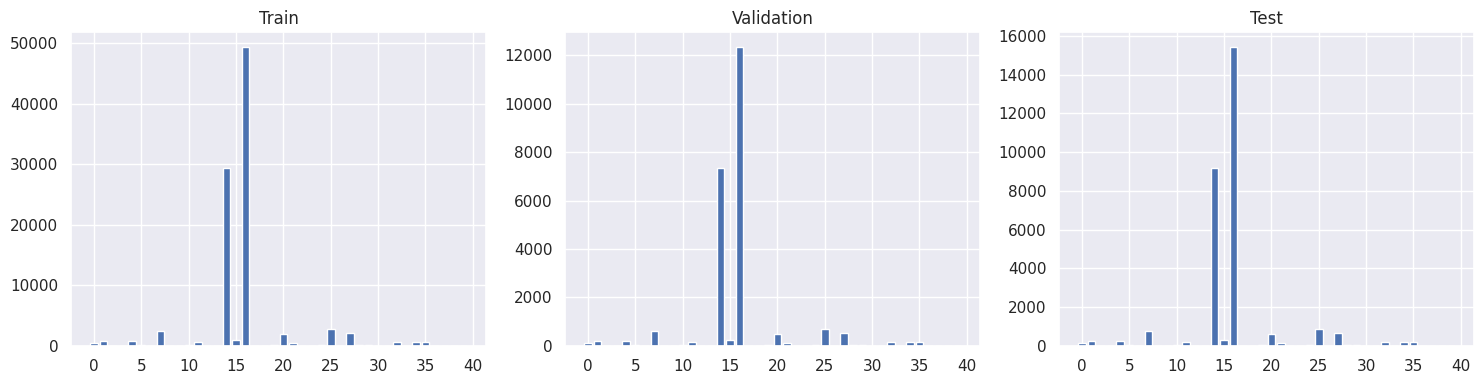

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Train
counts_train = np.bincount(y_train)
ax1.bar(np.arange(len(counts_train)), counts_train)
ax1.set_title("Train")

# Val
counts_val = np.bincount(y_val)
ax2.bar(np.arange(len(counts_val)), counts_val)
ax2.set_title("Validation")

# Test
counts_test = np.bincount(y_test)
ax3.bar(np.arange(len(counts_test)), counts_test)
ax3.set_title("Test")

plt.tight_layout()
plt.show()